# Exploratory Data Analysis

### Dataset Metadata
* **Name:** Telco Customer Churn Dataset (IBM)
* **Shape:** 7,043 rows × 33 columns

### Workflow:
* **Initial Analysis** - Inspecting the raw data distributions.
* **Data Cleaning** - Handling data types and anomalies.
* **Imputation** - Filling missing (`NaN`) values in the `Total Charges` column.
* **Data Backup** - Copying the cleaned dataframe to `df_model`.
* **Feature Selection** - Isolating columns for the model.

In [2]:
import pandas as pd
import numpy as np


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel(r"C:\Users\DELL\Documents\Churn Prediction\data\raw\Telco_customer_churn.xlsx"
)

In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [6]:
pd.set_option("display.max_columns", None)

df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
for col in["Count","Country","State"]:
    print(col,df[col].value_counts())

Count Count
1    7043
Name: count, dtype: int64
Country Country
United States    7043
Name: count, dtype: int64
State State
California    7043
Name: count, dtype: int64


In [8]:
df[["City", "Zip Code", "Lat Long", "Latitude", "Longitude"]].nunique()

City         1129
Zip Code     1652
Lat Long     1652
Latitude     1652
Longitude    1651
dtype: int64

- We are dropping few columns as they are not important.

In [9]:
geo_cols = [
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

df = df.drop(columns=geo_cols)

In [10]:
df = df.drop(["Country","State","Count"],axis=1)

In [11]:
df.head()

,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


- After dropping unimportant columns the shape is:

In [12]:
df.shape

(7043, 25)

## **Data Cleaning:**

- Let's check TotalCharges column as this is very important one


In [13]:
df[df["Total Charges"].astype(str).str.strip() == ""]

,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,0,36,2578,NaN
2438,3115-CZMZD,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,0,68,5504,NaN
2568,5709-LVOEQ,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,0,45,2048,NaN
2667,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,0,48,4950,NaN
2856,1371-DWPAZ,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,0,30,4740,NaN
4331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,0,53,2019,NaN
4687,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,0,49,2299,NaN
5104,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,0,27,3763,NaN
5719,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,0,69,4890,NaN
6772,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,0,44,2342,NaN


In [14]:
df["Total Charges"] = df["Total Charges"].replace(" ",pd.NA)

In [15]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [16]:
df.loc[
    df["Total Charges"].isna(),
    ["Tenure Months", "Monthly Charges", "Churn Label"] #To see those columns(tenure months,monthly charges,churn label) have null "total charges".
    ]

,Tenure Months,Monthly Charges,Churn Label
2234,0,52.55,No
2438,0,20.25,No
2568,0,80.85,No
2667,0,25.75,No
2856,0,56.05,No
4331,0,19.85,No
4687,0,25.35,No
5104,0,20.00,No
5719,0,19.70,No
6772,0,73.35,No


In [17]:
df["Total Charges"] = df["Total Charges"].fillna(0) #Fill them with 0 because the customer's are newly joined. 

In [18]:
df["Total Charges"].isna().sum()

np.int64(0)

## **Data Visualisation**

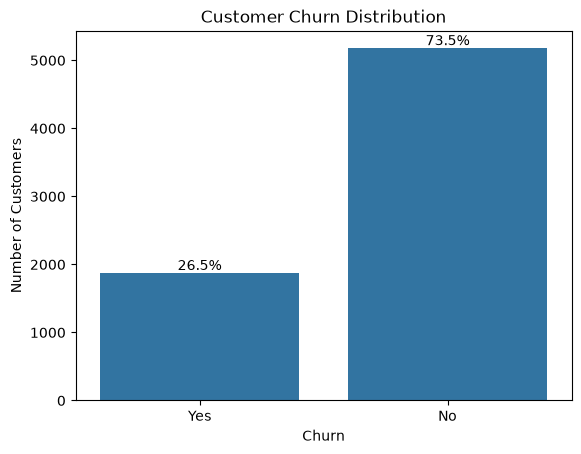

In [21]:
ax = sns.countplot(data=df, x="Churn Label")

total = len(df)

for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Churn")
plt.show()

In [ ]:
#Observation: The dataset contains 7,043 customers, of which 1,869 (26.5%) have churned and 5,174 (73.5%) have not churned. 
# The target variable is moderately imbalanced, with non-churned customers representing the majority of observations. 
# Therefore, model performance should not be evaluated using accuracy alone; 
# metrics such as precision, recall, F1-score, and ROC-AUC should also be considered.

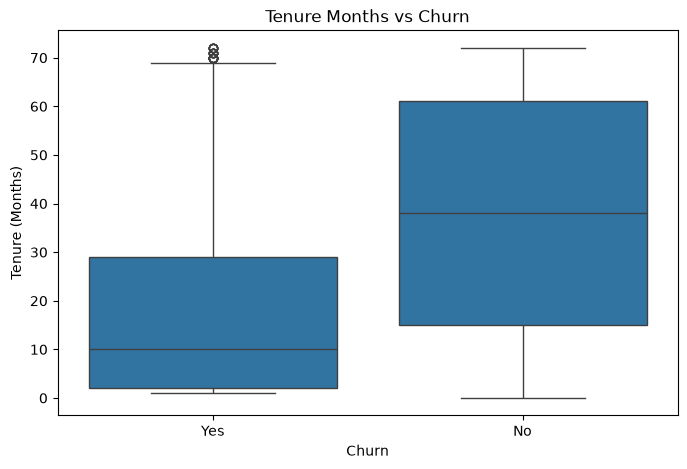

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Months vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [25]:
result = (
    df.groupby(
        pd.cut(
            df["Churn Score"],
            bins=[0, 50, 80, 100],
            include_lowest=True
        ),
        observed=False
    )["Churn Label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    * 100
)

result

Churn Label,No,Yes
Churn Score,,
"(-0.001, 50.0]",100.000000,0.000000
"(50.0, 80.0]",75.890492,24.109508
"(80.0, 100.0]",0.000000,100.000000


- **CHURN REASON:** It is very important column for RAG and LLM for later.
But it contains 5,174 missing values which is timewaste if we fill them or encode, because we don't neccessarily need this column to train our model. So we keep seperate this in our original dataset (df) and copy this to "df_model", and when we train model we drop this from feature variable [X].  

In [120]:
df_model = df.copy()

In [121]:
df_model.to_csv(

    "../data/preprocessed/churn_cleaned.csv",

    index=False

)

In [151]:
clean_cols = [
    "Online Security", "Online Backup", "Multiple Lines","Device Protection",
    "Tech Support","Streaming Movies","Streaming TV"]

for col in clean_cols:
    df_model[col] = df_model[col].astype(str).str.strip()
    
    df_model[col] = df_model[col].replace({
        "No phone service": "No",
        "No phone services": "No",
        "No internet service": "No",
        "No internet services": "No"
    })

## **Feature Selecton:**

In [123]:
high_churn_labels = df_model[df_model['Churn Score'] > 80]['Churn Label'] 
high_churn_labels.sample(10) 
#Observation: All the customers whose churn score is greater than 80 has churn label "Yes".

36      Yes
114     Yes
1320    Yes
311     Yes
98      Yes
1278    Yes
1277    Yes
1607    Yes
1604    Yes
1564    Yes
Name: Churn Label, dtype: str

In [124]:
low_churn_labels = df_model[df_model['Churn Score'] <=50]['Churn Label'] 
low_churn_labels.sample(15) 
#Observation: All the customers whose churn score is less than 50 has churn label "No".

3969    No
3187    No
3514    No
5318    No
4990    No
4809    No
3835    No
3483    No
6426    No
4549    No
2736    No
2030    No
2277    No
5584    No
2347    No
Name: Churn Label, dtype: str

- The Churn Score will cause data leakage, so dropping this column is important.

In [125]:
drop_cols = [
    'Churn Score',
    'Churn Reason',
    'CLTV',
    'Churn Value'
]
df_model = df_model.drop(columns=drop_cols)


- Correlation Matrix:


In [126]:
df_model["Churn_Label_Num"] = df_model["Churn Label"].map({ # map(): replacing values according to a dictionary.
    "No": 0,
    "Yes": 1
})

In [73]:
df_model.select_dtypes(include="object").columns.tolist()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19088\2940521981.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.select_dtypes(include="object").columns.tolist()


['CustomerID',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Total Charges',
 'Churn Label']

"Total Charges" --> numeric

In [128]:
df_model["Total Charges"] = pd.to_numeric(
    df_model["Total Charges"],
    errors="coerce"
)

In [129]:
df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
#This shows there are very less numeric cols in our data, we need to convert remaining object column that should be numeric

['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn_Label_Num']

In [130]:
numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

df_model[numeric_cols].corr()["Churn_Label_Num"].sort_values(ascending=False)

Churn_Label_Num    1.000000
Monthly Charges    0.193356
Total Charges     -0.198324
Tenure Months     -0.352229
Name: Churn_Label_Num, dtype: float64

- Churn Rate 

In [152]:
categorical_cols = df_model.select_dtypes(include="object").columns
pd.set_option('display.max_columns', None)
for col in categorical_cols:
    if col not in ["CustomerID", "Gender","Churn Label"]:
        print(f"\n--- {col} ---")
        print(
            pd.crosstab(
                df_model[col],
                df_model["Churn Label"],
                normalize="index"
            ).round(3) * 100
        )


--- Senior Citizen ---
Churn Label       No   Yes
Senior Citizen            
No              76.4  23.6
Yes             58.3  41.7

--- Partner ---
Churn Label    No   Yes
Partner                
No           67.0  33.0
Yes          80.3  19.7

--- Dependents ---
Churn Label    No   Yes
Dependents             
No           67.4  32.6
Yes          93.5   6.5

--- Phone Service ---
Churn Label      No   Yes
Phone Service            
No             75.1  24.9
Yes            73.3  26.7

--- Multiple Lines ---
Churn Label       No   Yes
Multiple Lines            
No              75.0  25.0
Yes             71.4  28.6

--- Internet Service ---
Churn Label         No   Yes
Internet Service            
DSL               81.0  19.0
Fiber optic       58.1  41.9
No                92.6   7.4

--- Online Security ---
Churn Label        No   Yes
Online Security            
No               68.7  31.3
Yes              85.4  14.6

--- Online Backup ---
Churn Label      No   Yes
Online Backup          

C:\Users\DELL\AppData\Local\Temp\ipykernel_19088\2088424647.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include="object").columns


_**Based on my EDA, these features don't provide enough independent signal to justify keeping them in my baseline model:**_

- Gender → very similar churn behavior between categories.

- Phone Service → very small difference in churn rate.

- Multiple Lines → small difference.

- Streaming TV → relatively weak relationship.

- Streaming Movies → relatively weak relationship.


In [153]:
#Dropping those features which don't provide enough independent signals.
drop_cols = [
    "CustomerID",
    "Gender",
    "Phone Service",
    "Multiple Lines",
    "Streaming TV",
    "Streaming Movies"
]

df_model = df_model.drop(columns=drop_cols)

In [157]:
df_model = df_model.drop(columns=["Churn_Label_Num"])

In [165]:
print("Shape: ",df_model.shape,"\n")
print("All columns in df_model: ",df_model.columns.tolist(),"\n")
print("missing values: ",df_model.isnull().sum().sum(),"\n")


Shape:  (7043, 15) 

All columns in df_model:  ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'] 

missing values:  0 



In [162]:
df_model.dtypes

Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
dtype: object

Save df_model


In [163]:
df_model.to_csv(
    "../data/preprocessed/churn_cleaned.csv",
    index=False
)

In [166]:
print("Shape: ",df_model.shape,"\n")
print("All columns in df_model: ",df_model.columns.tolist(),"\n")
print("missing values: ",df_model.isnull().sum().sum(),"\n")


Shape:  (7043, 15) 

All columns in df_model:  ['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label'] 

missing values:  0 



Numeric columns in df_model:

In [171]:
numeric_cols = df_model.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols

['Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical columns in df_model

In [172]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols

C:\Users\DELL\AppData\Local\Temp\ipykernel_19088\2061730049.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include='object').columns.tolist()


['Senior Citizen',
 'Partner',
 'Dependents',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Churn Label']